# **Analyse du papier de recherche Center-Based 3D Object Detection and Tracking** 

*Auteur :* Erwan Ouabdesselam

In [1]:
import os
import sys

import warnings
warnings.filterwarnings("ignore")

# Se placer à la racine du repo
os.chdir("..")
sys.path.append(".")

print("Working directory:", os.getcwd())

import numpy as np
import torch
import matplotlib
#matplotlib.use("Agg")

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyArrowPatch
from matplotlib.lines import Line2D


from pathlib import Path
from IPython.display import Image, display
import imageio
from tqdm import tqdm

# Imports nuScenes
from nuscenes.nuscenes import NuScenes
from nuscenes.utils.data_classes import LidarPointCloud, Box
from pyquaternion import Quaternion

# Imports du framework det3d
from det3d.torchie import Config
from det3d.datasets import build_dataset
from det3d.models import build_detector
from det3d.torchie.trainer import load_checkpoint


# Choix du device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)
print("PyTorch:", torch.__version__)

# Chemins principaux du projet
CFG_PATH = "configs/nusc/voxelnet/nusc_centerpoint_voxelnet_0075voxel_fix_bn_z_flip.py"
CKPT_PATH = "work_dirs/nusc_centerpoint/epoch_20.pth"
DATA_ROOT = "data/nuScenes"

# Chargement de la configuration du modèle
cfg = Config.fromfile(CFG_PATH)

cfg.data.val.root_path = DATA_ROOT
cfg.data.val.ann_file = "infos_val_10sweeps_withvelo_filter_True.pkl"
cfg.data.val.nsweeps = 10

# Construction du dataset de validation
val_dataset = build_dataset(cfg.data.val)
print("Dataset size:", len(val_dataset))

# Construction du modèle
model = build_detector(cfg.model, train_cfg=None, test_cfg=cfg.test_cfg)

# Chargement des poids entraînés
load_checkpoint(model, CKPT_PATH, map_location="cpu")

model = model.to(DEVICE).eval()

# Informations sur l'architecture
print("Model loaded")
print("Reader:", type(model.reader).__name__)
print("Backbone:", type(model.backbone).__name__)
print("Neck:", type(model.neck).__name__)
print("Head:", type(model.bbox_head).__name__)

Working directory: /home/r1/Analysis_of_CenterPoint
no apex
No Tensorflow
Deformable Convolution not built!
Device: cuda
PyTorch: 2.4.1+cu118
10
Dataset size: 81
Use HM Bias:  -2.19
Model loaded
Reader: VoxelFeatureExtractorV3
Backbone: SpMiddleResNetFHD
Neck: RPN
Head: CenterHead


# **Introduction**

### **Contexte : perception 3D pour la conduite autonome**

La détection d’objets en 3D constitue un élément fondamental des systèmes de conduite autonome.  
Contrairement à la détection 2D basée sur les images, la perception 3D repose souvent sur des nuages de points LiDAR, qui sont naturellement clairsemés et géométriquement irréguliers.

Plusieurs difficultés spécifiques apparaissent dans ce contexte :

- la majorité de l’espace observé ne contient aucune mesure ;
- les objets peuvent apparaître avec des orientations arbitraires dans le plan ;
- les différentes classes d’objets présentent des tailles et des formes très hétérogènes.

Ces caractéristiques rendent la détection d’objets en 3D sensiblement plus complexe que dans le cadre de la détection 2D classique.

---

### **Limites des détecteurs 3D *anchor-based***

De nombreuses méthodes de détection d’objets reposent sur le principe des *anchors*.  
Cette approche consiste à définir un ensemble de boîtes candidates prédéfinies, disposées sur une grille spatiale.  
Chaque ancre représente une hypothèse initiale sur la position et la taille d’un objet potentiel.

Lors de l’apprentissage, le réseau prédit pour chaque ancre :

- une probabilité de présence d’objet ;
- des corrections géométriques permettant d’ajuster la boîte prédéfinie afin de mieux correspondre à l’objet réel.

Cette stratégie s’est révélée particulièrement efficace pour la détection d’objets dans les images, où les boîtes sont généralement alignées avec les axes de l’image.

Cependant, son extension à la détection 3D est plus délicate.  
Les objets dans un nuage de points peuvent apparaître avec une grande variété d’orientations et de dimensions.  
Afin de couvrir cet espace de configurations, il devient nécessaire d’introduire un grand nombre d’ancres correspondant à différentes tailles et orientations possibles.

Cette multiplication des ancres entraîne plusieurs inconvénients :

- une augmentation du coût computationnel ;
- une assignation plus complexe des exemples positifs et négatifs pendant l’entraînement ;
- un risque accru de faux positifs dû au grand nombre d’hypothèses générées.

Ces limitations suggèrent que la difficulté du problème ne réside pas uniquement dans l’extraction de caractéristiques à partir du nuage de points, mais également dans la représentation choisie pour modéliser les objets détectés.  
Elles motivent ainsi l’exploration d’approches alternatives ne reposant pas sur des ancres prédéfinies.

---

### **Idée principale de l’approche center-based**

CenterPoint reformule le problème de détection : au lieu de prédire directement des boîtes 3D ancrées, le modèle détecte d’abord les *centres* d’objets en vue BEV (Bird’s Eye View), puis régresse leurs attributs géométriques.

Concrètement, le nuage de points LiDAR est d’abord encodé par un backbone 3D (par exemple VoxelNet ou PointPillars) afin de produire une représentation spatiale en vue BEV.  
Sur cette représentation, la détection est formulée comme un problème d’estimation de points clés, inspiré des approches center-based utilisées en détection 2D telles que CenterNet.

L’intuition est simple : une boîte 3D possède une orientation intrinsèque, alors qu’un point n’en possède pas. En détectant directement les centres des objets, le modèle évite d’énumérer explicitement un grand nombre d’hypothèses d’orientation.

Le pipeline suit alors deux étapes principales :

1. prédiction d’une heatmap de centres d’objets en vue BEV ;
2. régression, au centre détecté, des attributs géométriques : dimensions de la boîte, orientation (yaw), position verticale et vitesse.

Cette formulation réduit l’espace de recherche du détecteur, simplifie l’apprentissage et facilite naturellement l’intégration du suivi temporel des objets.

---

### **Contributions de CenterPoint**

Les contributions majeures de l’approche peuvent être résumées ainsi :

- une formulation *center-based* de la détection 3D qui supprime la dépendance aux ancres et réduit l’espace de recherche du détecteur ;
- une prédiction conjointe de la détection et du suivi d’objets grâce à l’estimation de la vitesse ;
- un module de raffinement léger en seconde étape permettant d’améliorer la précision des boîtes prédites ;
- une architecture simple et modulaire, compatible avec différents backbones LiDAR ;
- des performances de référence sur les benchmarks nuScenes et Waymo en détection 3D et en suivi multi-objets.



# **Analysis of the pipeline**

To better understand the architecture of CenterPoint, the overall pipeline can be decomposed into **four main components**, as illustrated in the diagram below that come from the paper. In the following sections, each component will be examined in detail to provide a clearer understanding of how the model processes LiDAR point cloud data to produce 3D object detections.


<p align="center">
<img src="figures/full_pipeline.png" width="800">
</p>

## **1. Point cloud representation**

To illustrate the CenterPoint pipeline, we use the **nuScenes dataset**, a large-scale benchmark designed for autonomous driving perception. The dataset provides synchronized data from a vehicle equipped with multiple sensors, including **1 LiDAR, 6 cameras, and 5 radars**. In this analysis, we focus exclusively on **LiDAR point clouds**, since CenterPoint operates directly on this modality for 3D object detection.

### **LiDAR measurements and frame representation**

A LiDAR (Light Detection and Ranging) sensor measures distances by emitting laser pulses and recording the time it takes for the reflected signal to return to the sensor. As the sensor rotates, successive laser beams scan the surrounding environment and generate a set of 3D points describing the scene. This collection of points is commonly referred to as a **point cloud**.

In the nuScenes dataset, each LiDAR frame is stored as a set of points:

$$
P = \{(x_i, y_i, z_i, r_i)\}_{i=1}^{N}
$$

where $x_i, y_i, z_i$ denote the spatial coordinates of the reflection and $r_i$ represents the reflectance intensity returned by the laser.

All points are expressed in the **ego-vehicle coordinate system**, centered on the LiDAR sensor mounted on the vehicle. In this coordinate frame:

- $x$ corresponds to the forward direction of the vehicle  
- $y$ corresponds to the lateral direction (left–right)  
- $z$ corresponds to the vertical direction  

This coordinate system provides a consistent spatial reference for representing the scene and predicting the **3D bounding boxes of surrounding objects**.

In practice, each LiDAR frame contains tens or hundreds of thousands of points describing surfaces such as roads, vehicles, buildings, and vegetation. Each point corresponds to a single laser reflection captured by the sensor.



In [5]:
# Charger le premier sample
nusc = NuScenes(
    version='v1.0-mini',
    dataroot="data/nuScenes",
    verbose=True)

sample_idx = 10
data = val_dataset[sample_idx]
info = val_dataset._nusc_infos[sample_idx]
sample_token = info["token"]
sample = nusc.get("sample", sample_token)

# Extraire le nuage de points (N, 5) : x, y, z, intensity, delta_t
points = data[0]['points']  # numpy array (N, 5)
print(f"Nuage de points shape : {points.shape}")
print(f"  x   : [{points[:,0].min():.1f}, {points[:,0].max():.1f}] m")
print(f"  y   : [{points[:,1].min():.1f}, {points[:,1].max():.1f}] m")
print(f"  z   : [{points[:,2].min():.1f}, {points[:,2].max():.1f}] m")
print(f"  int : [{points[:,3].min():.3f}, {points[:,3].max():.3f}]")
print(f"  Δt  : [{points[:,4].min():.3f}, {points[:,4].max():.3f}]")

# Valeurs uniques de Δt → nombre de sweeps effectifs
dt_vals = np.unique(np.round(points[:,4], 3))
print(f"\nNombre de sweeps distincts (Δt uniques) : {len(dt_vals)}")
print(f"Valeurs Δt : {dt_vals}")


Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.7 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.
Nuage de points shape : (269138, 5)
  x   : [-94.9, 82.1] m
  y   : [-92.6, 90.6] m
  z   : [-11.3, 15.4] m
  int : [0.000, 255.000]
  Δt  : [0.000, 0.450]

Nombre de sweeps distincts (Δt uniques) : 10
Valeurs Δt : [0.    0.05  0.1   0.15  0.2   0.25  0.3   0.349 0.4   0.45 ]


In our example, the first sample contains approximately **219k LiDAR points**, each described by **five features**:

$$
(x, y, z, \text{intensity}, \Delta t)
$$

where:

- $x, y, z$ are the spatial coordinates of the point  
- $\text{intensity}$ represents the reflectance of the surface hit by the laser beam  
- $\Delta t$ indicates the relative timestamp of the LiDAR sweep from which the point originates

CenterPoint aggregates multiple LiDAR sweeps to densify the point cloud. The $\Delta t$ feature allows the model to distinguish between points coming from different timestamps, which can provide useful temporal information about moving objects.

(bellek j'ia pas mentionner c'st quoi sweep)

### **Bird's Eye View representation**

CenterPoint performs detection in **Bird's Eye View (BEV)**.

The point cloud is projected onto the ground plane by ignoring the vertical coordinate $z$.  
In this representation, objects appear as oriented rectangles and distances are preserved.

This projection is particularly suitable for autonomous driving scenes. Most objects of interest (cars, pedestrians, cyclists) lie on the road surface and primarily move in the horizontal plane. Their orientation therefore corresponds to a **yaw rotation around the vertical axis**, while the vertical dimension contains relatively little information for localization.

As a result, projecting the scene into BEV removes one dimension while preserving most of the geometric information relevant for object detection.

The figure below shows a LiDAR frame together with the ground-truth 3D bounding boxes projected in BEV.

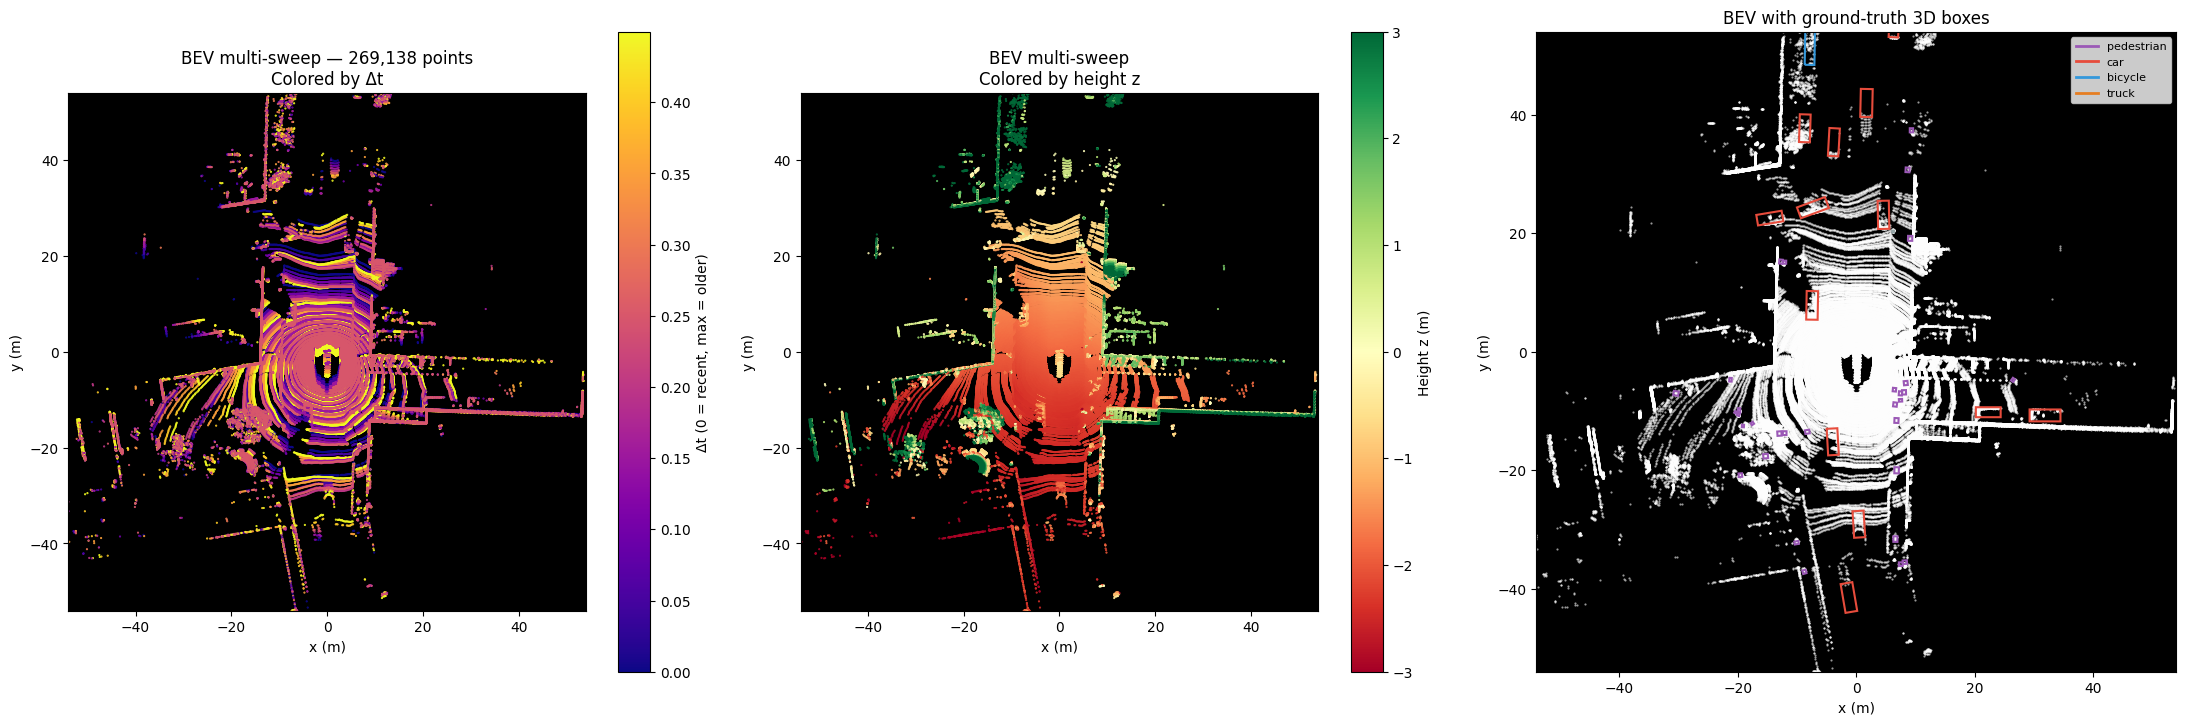

In [6]:
from matplotlib.lines import Line2D

# Helper function to extract Ground Truth annotations
def get_sample_boxes_in_lidar(nusc, sample):
    """
    Return all annotation boxes for a sample, transformed into the LiDAR sensor frame.
    """
    lidar_token = sample["data"]["LIDAR_TOP"]
    lidar_data = nusc.get("sample_data", lidar_token)

    cs = nusc.get("calibrated_sensor", lidar_data["calibrated_sensor_token"])
    ep = nusc.get("ego_pose", lidar_data["ego_pose_token"])

    boxes = []
    for ann_token in sample["anns"]:
        ann = nusc.get("sample_annotation", ann_token)

        box = Box(
            ann["translation"],
            ann["size"],
            Quaternion(ann["rotation"]),
            name=ann["category_name"]
        )

        # global → ego
        box.translate(-np.array(ep["translation"]))
        box.rotate(Quaternion(ep["rotation"]).inverse)

        # ego → sensor
        box.translate(-np.array(cs["translation"]))
        box.rotate(Quaternion(cs["rotation"]).inverse)

        boxes.append(box)

    return boxes


# Extract boxes
boxes = get_sample_boxes_in_lidar(nusc, sample)


# BEV visualization
fig, axes = plt.subplots(1, 3, figsize=(22, 7))


# --- 1 : colored by Δt ---
ax = axes[0]

dt = points[:, 4]

sc = ax.scatter(
    points[:, 0],
    points[:, 1],
    c=dt,
    s=0.3,
    cmap="plasma",
    vmin=0,
    vmax=dt.max(),
    rasterized=True
)

plt.colorbar(sc, ax=ax, label="Δt (0 = recent, max = older)")

ax.set_xlim(-54, 54)
ax.set_ylim(-54, 54)
ax.set_aspect("equal")

ax.set_title(f"BEV multi-sweep — {points.shape[0]:,} points\nColored by Δt")

ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")

ax.set_facecolor("black")
ax.grid(False)


# --- 2 : colored by height z ---
ax2 = axes[1]

z = points[:, 2]

sc2 = ax2.scatter(
    points[:, 0],
    points[:, 1],
    c=z,
    s=0.3,
    cmap="RdYlGn",
    vmin=-3,
    vmax=3,
    rasterized=True
)

plt.colorbar(sc2, ax=ax2, label="Height z (m)")

ax2.set_xlim(-54, 54)
ax2.set_ylim(-54, 54)
ax2.set_aspect("equal")

ax2.set_title("BEV multi-sweep\nColored by height z")

ax2.set_xlabel("x (m)")
ax2.set_ylabel("y (m)")

ax2.set_facecolor("black")
ax2.grid(False)


# --- 3 : point cloud + ground truth boxes ---
ax3 = axes[2]

ax3.scatter(points[:, 0], points[:, 1], s=0.3, c="white", alpha=0.6)

COLOR_MAP = {
    "car": "#e74c3c",
    "truck": "#e67e22",
    "bus": "#f1c40f",
    "trailer": "#f1c40f",
    "construction_vehicle": "#e67e22",
    "barrier": "#2ecc71",
    "motorcycle": "#3498db",
    "bicycle": "#3498db",
    "pedestrian": "#9b59b6",
    "traffic_cone": "#9b59b6",
}

legend_entries = {}

for box in boxes:


    cat = box.name.lower()

    cat_mapped = None
    for key in COLOR_MAP:
        if key in cat:
            cat_mapped = key
            break

    color = COLOR_MAP.get(cat_mapped, "#95a5a6")

    corners = box.bottom_corners()[:2, :]

    rect = plt.Polygon(
        corners.T,
        closed=True,
        fill=False,
        edgecolor=color,
        linewidth=1.5
    )

    ax3.add_patch(rect)

    if cat_mapped and cat_mapped not in legend_entries:
        legend_entries[cat_mapped] = color


handles = [
    Line2D([0], [0], color=c, lw=2, label=n)
    for n, c in legend_entries.items()
]

ax3.legend(handles=handles, loc="upper right", fontsize=8, framealpha=0.8)

ax3.set_xlim(-54, 54)
ax3.set_ylim(-54, 54)
ax3.set_aspect("equal")

ax3.set_title("BEV with ground-truth 3D boxes")

ax3.set_xlabel("x (m)")
ax3.set_ylabel("y (m)")

ax3.set_facecolor("black")
ax3.grid(False)


plt.tight_layout()
plt.show()

(est ce que je mets le gif ou pas ?)

### **Temporal structure**

nuScenes provides sequences of LiDAR frames. The LiDAR sensor operates at approximately **20 Hz**, meaning a new point cloud is captured every **50 milliseconds**. 

This temporal structure allows models such as CenterPoint to estimate **object velocities** and perform **tracking across frames**.

The following animation shows consecutive LiDAR frames together with their ground-truth bounding boxes.

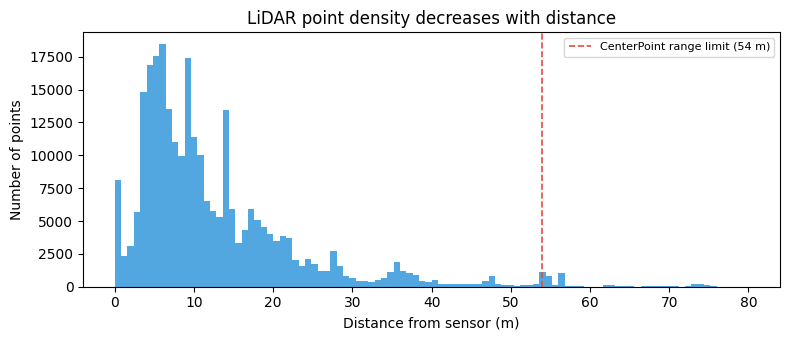

In [8]:
distances = np.linalg.norm(points[:, :2], axis=1)

fig, ax = plt.subplots(figsize=(8, 3.5))

ax.hist(
    distances,
    bins=100,
    range=(0, 80),
    color="#3498db",
    edgecolor="none",
    alpha=0.85
)

ax.set_xlabel("Distance from sensor (m)")
ax.set_ylabel("Number of points")

ax.set_title("LiDAR point density decreases with distance")

ax.axvline(
    x=54,
    color="#e74c3c",
    linestyle="--",
    linewidth=1.2,
    label="CenterPoint range limit (54 m)"
)

ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## **2. Voxelization of the LiDAR Point Cloud**

### **Motivation**

A LiDAR sensor captures the environment as a **point cloud** : a set of points
in 3D space. Unlike images, point clouds are **unordered and irregular**, there
is no underlying grid structure and the number of points varies from frame to
frame.

Convolutional neural networks, however, are designed to process **structured
inputs arranged on regular grids**. To apply them to LiDAR data, the point
cloud must first be converted into a structured spatial representation.

**Voxelization** is the standard solution: it discretizes the 3D space into
small volumetric cells called **voxels**, producing a regular grid that CNNs
can process.


### **Principle**

Voxelization divides the 3D space surrounding the ego vehicle into a regular
grid. Each voxel is defined by a spatial resolution $(\Delta x, \Delta y,
\Delta z)$. A point with coordinates $(x, y, z)$ is assigned to the voxel
$(i, j, k)$ computed as:

$$
i = \left\lfloor \frac{x - x_{\min}}{\Delta x} \right\rfloor, \quad
j = \left\lfloor \frac{y - y_{\min}}{\Delta y} \right\rfloor, \quad
k = \left\lfloor \frac{z - z_{\min}}{\Delta z} \right\rfloor
$$

All points falling inside the same voxel are grouped together. In practice,
only voxels that contain at least one point are stored, resulting in a
**sparse representation** that avoids allocating memory for empty space.


### **Two variants in the CenterPoint paper**

The CenterPoint paper evaluates two different voxelization strategies:

**VoxelNet-style (3D voxels)**  
The 3D space is discretized along all three spatial dimensions
$(x, y, z) \rightarrow (i, j, k)$.
Each voxel aggregates the points it contains into a feature vector.
These voxel features are then processed by a **sparse 3D convolutional
backbone**, which preserves the full 3D geometry of the scene before
projecting onto a BEV feature map.

**PointPillars-style (pillars)**  
The vertical dimension is collapsed: the space is discretized only along the
ground plane $(x, y) \rightarrow (i, j)$, and each cell corresponds to a
vertical column called a **pillar**. This enables the use of **2D
convolutional networks**, which are significantly faster but lose some
vertical geometric information.

The paper shows that the VoxelNet variant achieves higher accuracy, while
the PointPillars variant is faster. In this notebook we focus on the
**VoxelNet formulation**.


### **CenterPoint implementation**

CenterPoint uses the following parameters for the VoxelNet variant:

| Parameter | Value | Description |
|-----------|-------|-------------|
| Voxel size | [0.075, 0.075, 0.2] m | (Δx, Δy, Δz) spatial resolution |
| Point cloud range | [−54, −54, −5, 54, 54, 3] m | Detection zone |
| Max points per voxel | 10 | If exceeded, points are randomly subsampled |
| Max voxels | 120 000 (test) | GPU memory cap |

Each point carries **5 features**: $(x,\ y,\ z,\ \text{intensity},\ \Delta t)$.
The $\Delta t$ feature encodes the temporal offset of the point relative to
the current sweep, and is specific to the multi-sweep aggregation used by
CenterPoint (10 sweeps).

Once points are grouped into voxels, the features of all points inside a
voxel are **averaged** (MeanVFE) to produce a single feature vector per
voxel. This is intentionally simple: no learnable parameters are involved at
this stage.

> The choice of voxelization hyperparameters (voxel size, range, max points)
> significantly impacts both accuracy and inference speed. We will study this
> trade-off in detail in a dedicated experiment section.


In [9]:
from det3d.ops.point_cloud.point_cloud_ops import points_to_voxel

VOXEL_SIZE = [0.075, 0.075, 0.2]
PC_RANGE   = [-54, -54, -5, 54, 54, 3]
MAX_POINTS = 10
MAX_VOXELS = 120000

voxels, coordinates, num_points_per_voxel = points_to_voxel(
    points, VOXEL_SIZE, PC_RANGE, MAX_POINTS,
    reverse_index=True, max_voxels=MAX_VOXELS
)

# Dimensions théoriques de la grille
grid_x = int((PC_RANGE[3] - PC_RANGE[0]) / VOXEL_SIZE[0])  # 1440
grid_y = int((PC_RANGE[4] - PC_RANGE[1]) / VOXEL_SIZE[1])  # 1440
grid_z = int((PC_RANGE[5] - PC_RANGE[2]) / VOXEL_SIZE[2])  # 40
total_voxels = grid_x * grid_y * grid_z

sparsity = voxels.shape[0] / total_voxels * 100

print(f"Output shapes:")
print(f"  voxels      : {voxels.shape}  → (N_voxels, max_points, 5 features)")
print(f"  coordinates : {coordinates.shape}  → (N_voxels, 3) indices (z, y, x)")
print(f"  num_points  : {num_points_per_voxel.shape}")
print()
print(f"Theoretical grid : {grid_x} × {grid_y} × {grid_z} = {total_voxels:,} voxels")
print(f"Occupied voxels  : {voxels.shape[0]:,} / {MAX_VOXELS:,}")
print(f"Sparsity         : {sparsity:.4f}% occupied  → extremely sparse")
print()
print(f"Points per voxel — min: {num_points_per_voxel.min()}  "
      f"max: {num_points_per_voxel.max()}  "
      f"mean: {num_points_per_voxel.mean():.2f}")


Output shapes:
  voxels      : (108911, 10, 5)  → (N_voxels, max_points, 5 features)
  coordinates : (108911, 3)  → (N_voxels, 3) indices (z, y, x)
  num_points  : (108911,)

Theoretical grid : 1440 × 1440 × 40 = 82,944,000 voxels
Occupied voxels  : 108,911 / 120,000
Sparsity         : 0.1313% occupied  → extremely sparse

Points per voxel — min: 1  max: 10  mean: 2.20


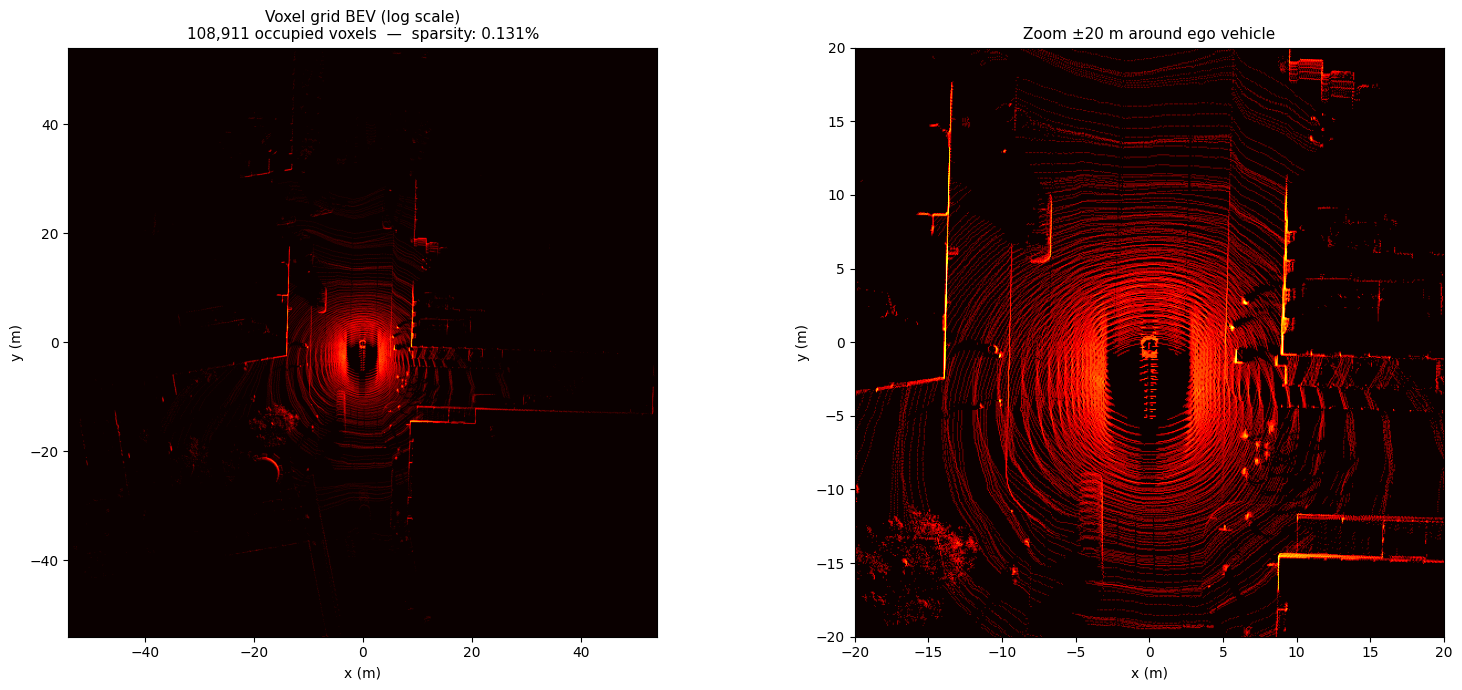

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Construire la grille BEV (projection selon z, somme des points)
bev_grid = np.zeros((grid_y, grid_x), dtype=np.float32)
for coord, npts in zip(coordinates, num_points_per_voxel):
    y_idx, x_idx = int(coord[1]), int(coord[2])
    if 0 <= y_idx < grid_y and 0 <= x_idx < grid_x:
        bev_grid[y_idx, x_idx] += npts

extent = [PC_RANGE[0], PC_RANGE[3], PC_RANGE[1], PC_RANGE[4]]

# Vue globale
ax = axes[0]
ax.imshow(np.log1p(bev_grid), cmap='hot', origin='lower', extent=extent, aspect='equal')
ax.set_title(f'Voxel grid BEV (log scale)\n{voxels.shape[0]:,} occupied voxels  —  sparsity: {sparsity:.3f}%',
             fontsize=11)
ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')

# Zoom ±20 m autour du véhicule ego
ax2 = axes[1]
zoom_m = 20
cx, cy = grid_x // 2, grid_y // 2
zpx = int(zoom_m / VOXEL_SIZE[0])
sub = bev_grid[cy - zpx:cy + zpx, cx - zpx:cx + zpx]
ax2.imshow(np.log1p(sub), cmap='hot', origin='lower',
           extent=[-zoom_m, zoom_m, -zoom_m, zoom_m], aspect='equal')
ax2.set_title(f'Zoom ±{zoom_m} m around ego vehicle', fontsize=11)
ax2.set_xlabel('x (m)'); ax2.set_ylabel('y (m)')

plt.tight_layout()
plt.savefig('voxel_grid_bev.png', dpi=120, bbox_inches='tight')
plt.show()


The voxel grid reveals the characteristic structure of a LiDAR point cloud.
The concentric ring patterns reflect the rotational scanning mechanism of the
sensor: each ring corresponds to one full revolution, and the spacing between
rings increases with distance as point density decreases.

Only **0.131%** of the theoretical grid is occupied (108,911 voxels out of
~83 million). This extreme sparsity is the key motivation for using sparse
convolutional networks: a dense 3D convolution over a 1440×1440×40 grid would
be computationally intractable, whereas sparse convolutions operate only on
occupied voxels.

The zoom around the ego vehicle confirms that fine geometric structures,
walls, building facades, parked vehicles, are well preserved at the 7.5 cm
resolution used by CenterPoint.


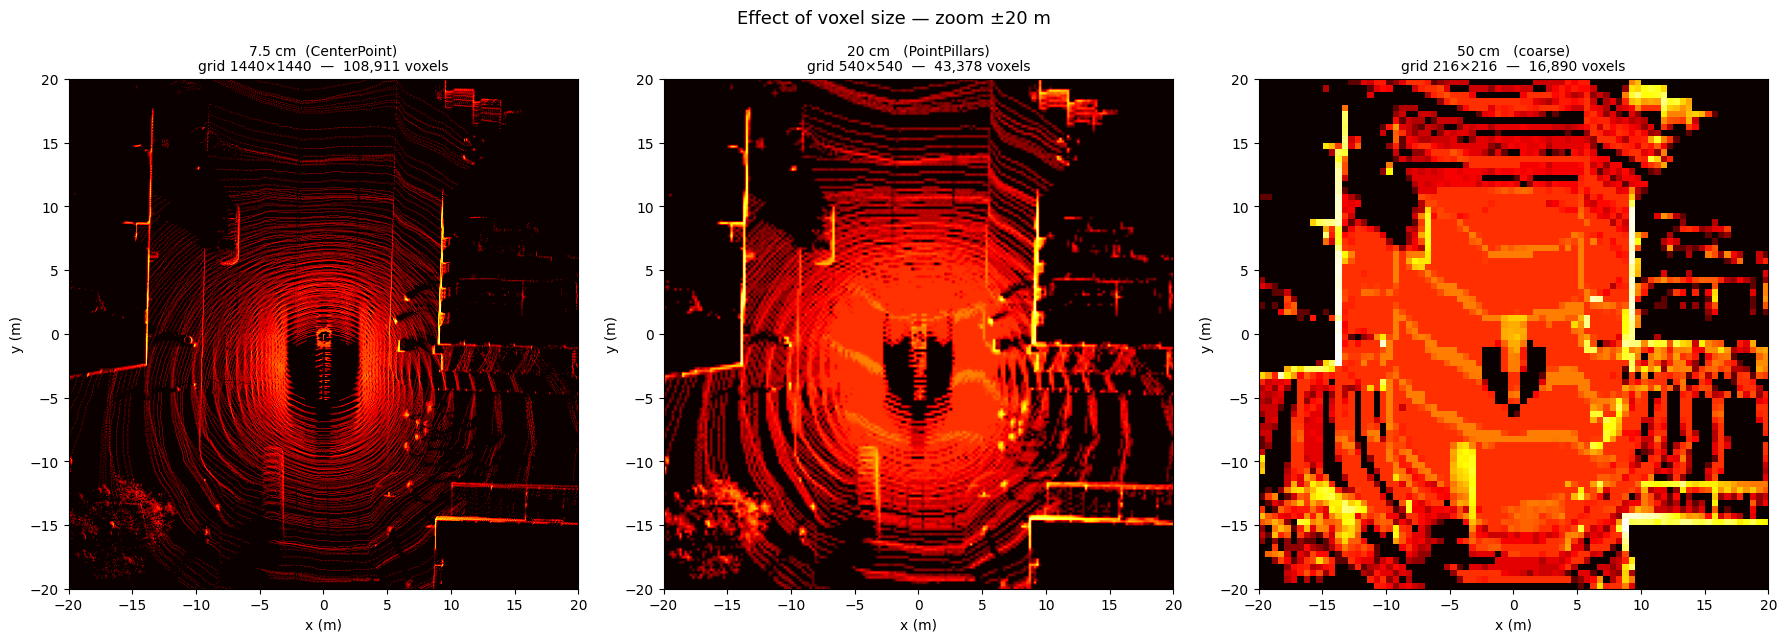

In [11]:
SIZES = {
    '7.5 cm  (CenterPoint)': [0.075, 0.075, 0.2],
    '20 cm   (PointPillars)': [0.20,  0.20,  0.2],
    '50 cm   (coarse)':       [0.50,  0.50,  0.2],
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (label, vs) in zip(axes, SIZES.items()):
    vox_i, coo_i, npts_i = points_to_voxel(
        points, vs, PC_RANGE, MAX_POINTS,
        reverse_index=True, max_voxels=MAX_VOXELS
    )

    gx = int((PC_RANGE[3] - PC_RANGE[0]) / vs[0])
    gy = int((PC_RANGE[4] - PC_RANGE[1]) / vs[1])
    grid_i = np.zeros((gy, gx), dtype=np.float32)
    for coord, npts in zip(coo_i, npts_i):
        yi, xi = int(coord[1]), int(coord[2])
        if 0 <= yi < gy and 0 <= xi < gx:
            grid_i[yi, xi] += npts

    # Zoom ±20 m
    zoom_m = 20
    cx_i, cy_i = gx // 2, gy // 2
    zpx_i = int(zoom_m / vs[0])
    sub_i = grid_i[cy_i - zpx_i:cy_i + zpx_i, cx_i - zpx_i:cx_i + zpx_i]

    ax.imshow(np.log1p(sub_i), cmap='hot', origin='lower',
              extent=[-zoom_m, zoom_m, -zoom_m, zoom_m], aspect='equal')
    ax.set_title(f'{label}\ngrid {gx}×{gy}  —  {vox_i.shape[0]:,} voxels', fontsize=10)
    ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')

plt.suptitle('Effect of voxel size — zoom ±20 m', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('voxel_size_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


The three grids illustrate the resolution trade-off introduced by the voxel
size parameter:

- **7.5 cm (CenterPoint default):** Individual scan rings remain distinct and
  fine geometric structures are preserved. A pedestrian or a narrow pole
  occupies several voxels, making it detectable. The grid is large
  (1440×1440) but sparse convolutions make it tractable.

- **20 cm (PointPillars default):** The geometry is still recognizable but
  scan rings begin to merge. Small objects start to blur into their
  surroundings. The grid is 7× smaller (540×540), which reduces memory and
  computation significantly.

- **50 cm (coarse):** Geometric detail is largely destroyed. Distinct
  structures fuse into large blocks, and the yellow saturation highlights
  voxels accumulating hundreds of points, information that was previously
  distributed across many fine voxels is now collapsed into a few coarse
  ones. At this resolution, detecting small objects such as pedestrians or
  cyclists becomes unreliable.

This comparison justifies the choice of a small voxel size in CenterPoint,
at the cost of a larger grid that requires sparse 3D convolutions to remain
efficient.


### **Output of the voxelization stage** (on enlève cette cellule ?)

The voxelization produces three tensors that serve as input to the backbone:

| Tensor | Shape | Content |
|--------|-------|---------|
| `voxels` | $(N_{vox},\ P,\ 5)$ | Raw point features grouped by voxel |
| `coordinates` | $(N_{vox},\ 3)$ | Grid indices $(z, y, x)$ of each occupied voxel |
| `num_points` | $(N_{vox},)$ | Actual point count per voxel (used to mask padding in MeanVFE) |

These three tensors are passed to the **VoxelFeatureExtractorV3** (MeanVFE),
which reduces the $(N_{vox}, P, 5)$ tensor to $(N_{vox}, 5)$ by averaging
along the points dimension — ignoring padding zeros thanks to `num_points`.

The resulting sparse voxel features, together with their coordinates, are
then fed into the **SpMiddleResNetFHD** sparse 3D backbone.


### **Voxel Feature Encoding — MeanVFE**

After voxelization, each occupied voxel contains a variable number of points
(between 1 and `max_points=10`), all padded to the same size with zeros.
The backbone cannot work with this variable-length structure — it needs
**exactly one feature vector per voxel**.

This is the role of the **Voxel Feature Extractor (VFE)**: aggregate the
points inside each voxel into a single fixed-size vector.

CenterPoint uses the simplest possible aggregation: the **mean** of the
features of all real points in the voxel (padding zeros are excluded using
`num_points`):

$$
\mathbf{f}_{voxel} = \frac{1}{k} \sum_{i=1}^{k} \mathbf{p}_i
\quad \text{where } k \text{ is the actual number of points in the voxel}
$$

$$
(N_{vox},\ P,\ 5) \xrightarrow{\text{MeanVFE}} (N_{vox},\ 5)
$$

This operation has **no learnable parameters** — it is a pure averaging step.
VoxelNet's original paper used a small PointNet-style network per voxel for
richer aggregation, but CenterPoint deliberately replaces it with a mean to
reduce computational cost, with negligible impact on accuracy.


In [12]:
import torch

voxel_tensor   = torch.tensor(voxels, dtype=torch.float32).to(DEVICE)
coords_tensor  = torch.tensor(coordinates, dtype=torch.int32).to(DEVICE)
num_pts_tensor = torch.tensor(num_points_per_voxel, dtype=torch.int32).to(DEVICE)

# Ajouter l'index de batch (batch_size=1)
batch_idx    = torch.zeros((coords_tensor.shape[0], 1), dtype=torch.int32, device=DEVICE)
batch_coords = torch.cat([batch_idx, coords_tensor], dim=1)  # (N_vox, 4)

with torch.no_grad():
    encoded = model.reader(voxel_tensor, num_pts_tensor, batch_coords)

print(f"Entrée  : {voxel_tensor.shape}  — (N_vox, max_points, 5)")
print(f"Sortie  : {encoded.shape}        — (N_vox, 5)")
print()

# Vérification manuelle sur 3 voxels
print("Vérification MeanVFE :")
print(f"{'Voxel':<8} {'k pts':<8} {'Moyenne manuelle':<45} {'Sortie reader':<45} {'OK'}")
print("-" * 120)
for idx in [0, 100, 1000]:
    k          = num_points_per_voxel[idx]
    manual     = voxels[idx, :k, :].mean(axis=0)
    from_model = encoded[idx].cpu().numpy()
    ok         = np.allclose(manual, from_model, atol=1e-4)
    print(f"{idx:<8} {k:<8} {str(np.round(manual, 4)):<45} {str(np.round(from_model, 4)):<45} {'✓' if ok else '✗'}")


Entrée  : torch.Size([108911, 10, 5])  — (N_vox, max_points, 5)
Sortie  : torch.Size([108911, 5])        — (N_vox, 5)

Vérification MeanVFE :
Voxel    k pts    Moyenne manuelle                              Sortie reader                                 OK
------------------------------------------------------------------------------------------------------------------------
0        10       [-3.1291 -0.4153 -1.8996  3.9     0.0998]     [-3.1291 -0.4153 -1.8996  3.9     0.0998]     ✓
100      3        [-13.8795  -0.1058   1.5226  21.3333   0.0999] [-13.8795  -0.1058   1.5226  21.3333   0.0999] ✓
1000     10       [-13.7822   3.1825   0.8615  23.4      0.2247] [-13.7822   3.1825   0.8615  23.4      0.2247] ✓


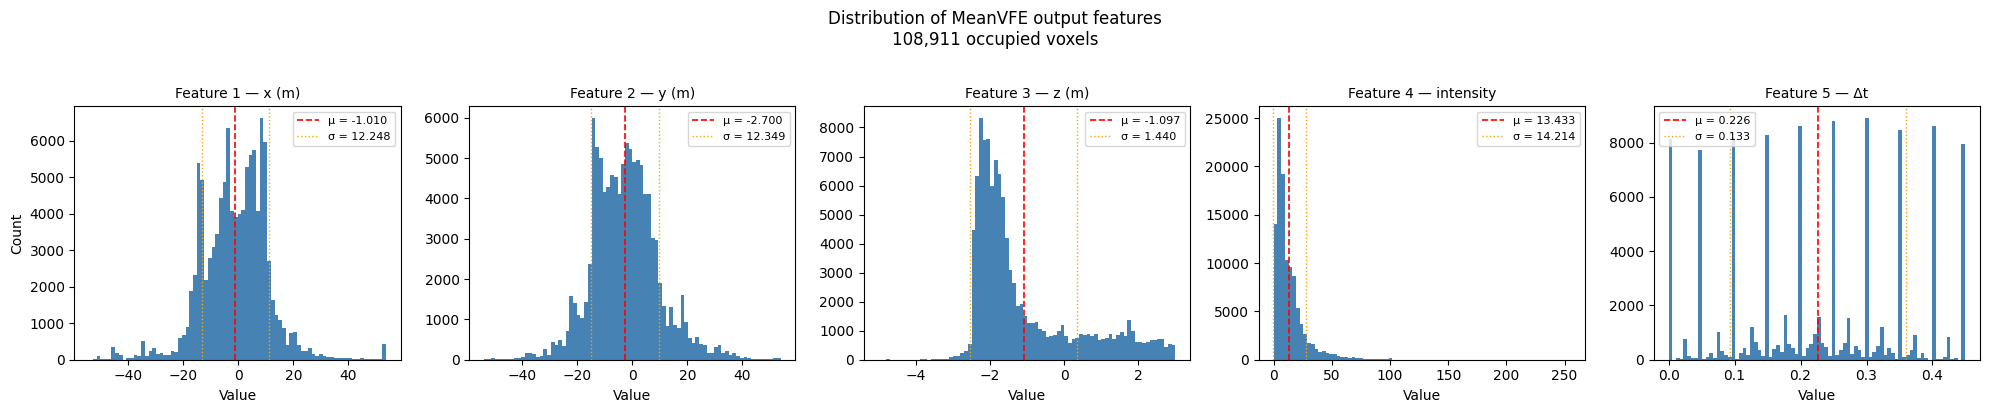

In [ ]:
encoded_np = encoded.cpu().numpy()  # (N_vox, 5)
FEATURE_NAMES = ['x (m)', 'y (m)', 'z (m)', 'intensity', 'Δt']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, (ax, fname) in enumerate(zip(axes, FEATURE_NAMES)):
    vals = encoded_np[:, i]
    ax.hist(vals, bins=80, color='steelblue', edgecolor='none')
    ax.axvline(vals.mean(), color='red', linestyle='--', linewidth=1.2,
               label=f'μ = {vals.mean():.3f}')
    ax.axvline(vals.mean() - vals.std(), color='orange', linestyle=':', linewidth=1)
    ax.axvline(vals.mean() + vals.std(), color='orange', linestyle=':', linewidth=1,
               label=f'σ = {vals.std():.3f}')
    ax.set_title(f'Feature {i+1} — {fname}', fontsize=10)
    ax.set_xlabel('Value'); ax.set_ylabel('Count' if i == 0 else '')
    ax.legend(fontsize=8)

plt.suptitle(f'Distribution of MeanVFE output features\n'
             f'{encoded_np.shape[0]:,} occupied voxels', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


The verification confirms that the reader output is exactly the per-voxel
mean of the raw point features, no transformation is applied.

The feature distributions reveal several properties of the encoded
representation:

- **x and y** are slightly off-center (μ ≈ −1.0 m and −2.7 m respectively),
  reflecting the actual position of the ego vehicle within the scene rather
  than being perfectly centered at the origin. Both features span the full
  detection range [−54, 54] m, with higher density close to the ego vehicle
  where point coverage is denser.

- **z** shows two distinct peaks: one around −1 m corresponding to
  ground-level returns, and one around 0.5 m corresponding to vehicle
  rooftops and obstacles. The distribution spans [−4, 3] m, consistent with
  the configured detection range [−5, 3] m.

- **intensity** is strongly right-skewed: most surfaces produce weak returns
  (values close to 0), while a small number of highly reflective surfaces
  such as road markings and traffic signs produce strong peaks near 255.

- **Δt** shows 10 discrete peaks, one per aggregated sweep, each contributing
  a roughly equal number of voxels. This feature is what allows the backbone
  to implicitly reason about object motion across time.

These 5-dimensional voxel features, together with their 3D coordinates, are
passed as a sparse tensor to the **SpMiddleResNetFHD** backbone.


## **3. Sparse 3D Backbone and BEV Feature Map**


### **Sparse 3D Backbone and BEV Feature Map**

Once each voxel has been encoded into a feature vector, the model can start learning **spatial patterns** in the scene.

A naive approach would apply standard 3D convolutions on the full voxel grid.  
However, most voxels are empty, which would make the computation extremely inefficient.

CenterPoint therefore uses **sparse convolutions**, which only perform computations on **occupied voxels**.

The sparse convolutional backbone progressively:

- aggregates spatial information across neighboring voxels
- increases the number of feature channels
- reduces the spatial resolution

Finally, the vertical dimension is collapsed, producing a dense **Bird's-Eye View (BEV) feature map**.

In [23]:
from det3d.models.backbones.scn import SpMiddleResNetFHD

# Initialize Backbone
backbone = SpMiddleResNetFHD(num_input_features=4, ds_factor=8).to(device)
backbone.eval()

# Format coordinates for Sparse Conv (add Batch index column)
coors_tensor = torch.tensor(coordinates, dtype=torch.int32, device=device)
batch_coors = F.pad(coors_tensor, (1, 0), mode='constant', value=0)

input_shape = [1440, 1440, 40] 

with torch.no_grad():
    map_view_features, _ = backbone(encoded_voxels, batch_coors, 1, input_shape)

print(f"✅ Flattened to 2D!")
print(f"Map View Features shape: {map_view_features.shape}")
print(f"-> Batch: {map_view_features.shape[0]}, Channels: {map_view_features.shape[1]}, Height/Width: {map_view_features.shape[2]}x{map_view_features.shape[3]}")


✅ Flattened to 2D!
Map View Features shape: torch.Size([1, 256, 180, 180])
-> Batch: 1, Channels: 256, Height/Width: 180x180


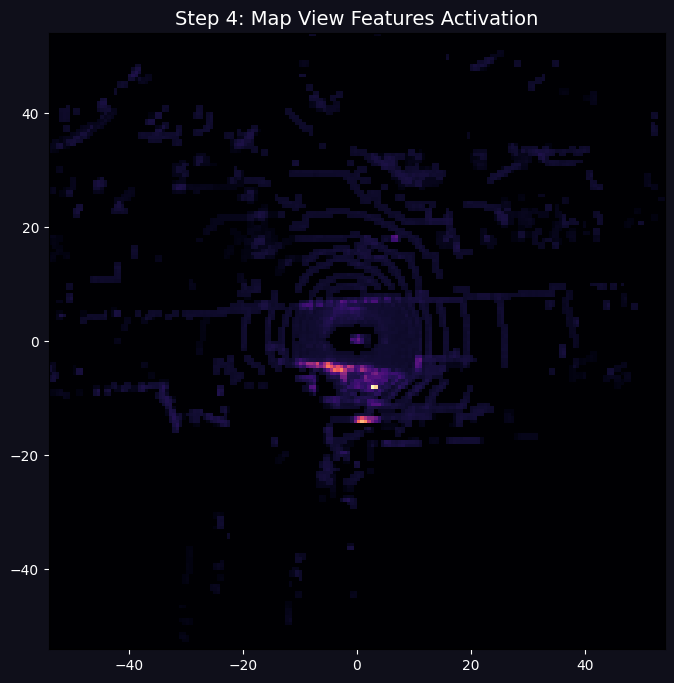

In [24]:
# Visualize Map View Features (Mean Activation)
mean_act = np.mean(map_view_features.squeeze(0).cpu().numpy(), axis=0)

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(np.log1p(np.abs(mean_act.T)), origin="lower", cmap="magma", extent=[-54, 54, -54, 54])
ax.set_title("Step 4: Map View Features Activation", color="white", fontsize=14)
ax.tick_params(colors="white"); fig.patch.set_facecolor("#0f0f1a")
plt.show()


The figure above shows the average activation of the BEV feature map produced by the backbone.

Even though the network is not trained here, the spatial structure of the scene is still visible.  
Dense regions correspond to areas where many voxels contribute to the learned features.

This BEV representation is crucial because it transforms the 3D perception problem into a **2D detection task**, enabling efficient convolutional processing.

### **Detection Head: Center-Based Object Detection**

Once the BEV feature map has been computed, the remaining steps follow the **CenterPoint detection paradigm**.

The architecture includes two components:

**Neck (Feature Pyramid Network)**

The neck aggregates features at multiple spatial scales.  
This allows the model to detect both small objects (e.g. pedestrians) and large ones (e.g. trucks).

---

**CenterHead**

Instead of predicting bounding boxes directly, CenterPoint predicts a **heatmap of object centers**.

Each pixel of the heatmap represents the probability that the center of an object lies at that location.

Bounding box parameters are then predicted around these centers.

In [29]:
from det3d.models.necks.rpn import RPN
from det3d.models.bbox_heads.center_head import CenterHead

import logging
logger = logging.getLogger("centerpoint")

# Initialize Neck
neck = RPN(
    layer_nums=[5, 5],
    ds_layer_strides=[1, 2],
    ds_num_filters=[128, 256],
    us_layer_strides=[1, 2],
    us_num_filters=[256, 256],
    num_input_features=256,
    logger=logger
).to(device)

neck.eval()

# Initialize CenterHead (Car only)
tasks = [dict(num_class=1, class_names=["car"])]

head = CenterHead(
    in_channels=512,
    tasks=tasks,
    dataset="nuscenes",
    common_heads={
        "reg": (2, 2),
        "height": (1, 2),
        "dim": (3, 2),
        "rot": (2, 2),
        "vel": (2, 2)
    }
).to(device)

head.eval()

with torch.no_grad():

    # Run Neck
    neck_features = neck(map_view_features)



    print(f"Neck Output: {neck_features.shape} -> [1, 512, 180, 180]")

    # Run CenterHead
    preds_dicts, _ = head(neck_features)

    # Car heatmap
    car_heatmap = torch.sigmoid(preds_dicts[0]["hm"])

print(f"Heatmap Output: {car_heatmap.shape} -> [1 Batch, 1 Class, 180 H, 180 W]")

Use HM Bias:  -2.19
Neck Output: torch.Size([1, 512, 180, 180]) -> [1, 512, 180, 180]
Heatmap Output: torch.Size([1, 1, 180, 180]) -> [1 Batch, 1 Class, 180 H, 180 W]


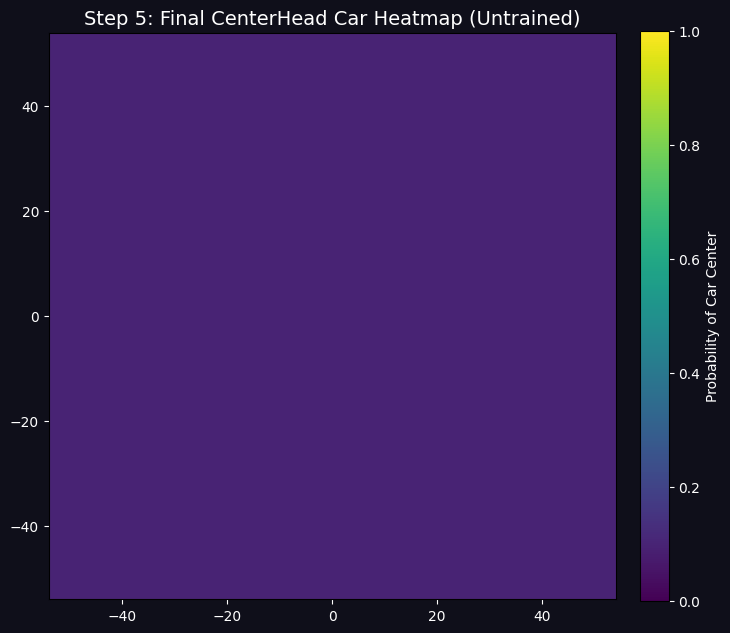

🏁 Pipeline complete! The peaks in this heatmap are the exact centers of predicted objects.


In [30]:
# Visualize the untrained Heatmap Prediction
heatmap_np = car_heatmap.squeeze().cpu().numpy()

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(heatmap_np.T, origin="lower", cmap="viridis", extent=[-54, 54, -54, 54], vmin=0, vmax=1)
ax.set_title("Step 5: Final CenterHead Car Heatmap (Untrained)", color="white", fontsize=14)
ax.tick_params(colors="white"); fig.patch.set_facecolor("#0f0f1a")
cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.set_label("Probability of Car Center", color="white")
cbar.ax.tick_params(colors="white")
plt.show()

print("🏁 Pipeline complete! The peaks in this heatmap are the exact centers of predicted objects.")
# Note: Because these layers are randomly initialized (untrained), the heatmap looks like noise.
# If we loaded the pre-trained weights (`centerpoint.pth`), we would see sharp Gaussian peaks exactly over the cars!


The heatmap above represents the predicted probability of an object center at each location in the BEV plane.

Since the network weights are randomly initialized, the heatmap currently appears as noise.

With trained weights, the model would produce **sharp Gaussian peaks** centered on the true object locations, allowing the detector to localize objects accurately.

# **3. Full Pipeline with Pre-trained Weights**

### **From Randomly Initialized Weights to a Real Detector**

The previous sections traced the CenterPoint pipeline step by step using **randomly initialized weights**,
which was useful to understand the shape and role of every intermediate tensor.
However, the heatmap produced was pure noise — no meaningful detection was possible.

In this section we load the **official pre-trained checkpoint** (`epoch_20.pth`, trained for 20 epochs on nuScenes)
and run the full pipeline on a real scene from the mini validation set.

| Aspect | Manual pipeline (sections 1–2) | Real CenterPoint (this section) |
|---|---|---|
| Input features | 4 (x, y, z, intensity) | **5** (x, y, z, intensity, Δt) |
| LiDAR sweeps | 1 frame | **10 aggregated sweeps** |
| Weights | Random | **Pre-trained (epoch 20)** |
| Tasks | Car only | **6 task groups (10 classes)** |


### **Why 5 Features? Multi-Sweep Aggregation**

The real CenterPoint model uses **10 consecutive LiDAR sweeps** aggregated into a single point cloud.
Each sweep is registered into the current ego frame using the known vehicle odometry.

For each point coming from a **past sweep**, a 5th feature $\Delta t$ (timestamp offset in seconds) is appended:

$$p_i = (x_i, y_i, z_i, \text{intensity}_i, \Delta t_i)$$

This gives the network **implicit motion cues**: points from moving objects appear at different positions
across sweeps, while static infrastructure (buildings, road) stacks perfectly.
The network can therefore learn to estimate **object velocity** directly from the point cloud,
which is the key enabling factor for the CenterPoint tracking module.


In [ ]:
import sys, logging, pickle
import torch, numpy as np, matplotlib.pyplot as plt
from matplotlib.lines import Line2D

sys.path.insert(0, ".")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

from det3d.torchie import Config
from det3d.datasets import build_dataset
from det3d.models import build_detector
from det3d.torchie.trainer import load_checkpoint

CONFIG_PATH = "configs/nusc/voxelnet/nusc_centerpoint_voxelnet_0075voxel_fix_bn_z_flip.py"
CKPT_PATH   = "work_dirs/nusc_centerpoint/epoch_20.pth"

cfg = Config.fromfile(CONFIG_PATH)
trained_model = build_detector(cfg.model, train_cfg=None, test_cfg=cfg.test_cfg)
trained_model = trained_model.to(device)
trained_model.eval()
load_checkpoint(trained_model, CKPT_PATH, map_location="cpu")

print(f"Pre-trained CenterPoint loaded  (epoch 20)")
print(f"Device : {device}")
print(f"Tasks  : {[t['class_names'] for t in cfg.model['bbox_head']['tasks']]}")


In [ ]:
val_dataset = build_dataset(cfg.data.val)
print(f"Validation set size: {len(val_dataset)} samples")

# dataset[i] → list of dicts (one per flip with double_flip=True); [0] = unflipped
sample_data = val_dataset[0][0]
print("Data dict keys:", list(sample_data.keys()))

# data['points'] est un numpy array (N, 5) sorti du pipeline Reformat
# np.asarray() est idempotent: fonctionne sur numpy array ET torch.Tensor
pts_ms = np.asarray(sample_data['points'], dtype=np.float32)  # shape (N, 5)
print(f"\nPoint cloud : {pts_ms.shape[0]:,} points x {pts_ms.shape[1]} features")
print(f"  x in [{pts_ms[:,0].min():.1f}, {pts_ms[:,0].max():.1f}] m")
print(f"  Dt in [{pts_ms[:,4].min():.3f}, {pts_ms[:,4].max():.3f}] s  (0 = current sweep)")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor("#0f0f1a")

ax = axes[0]
ax.scatter(pts_ms[:, 0], pts_ms[:, 1], s=0.25, c="white", alpha=0.5)
ax.set_facecolor("#1a1a2e")
ax.set_xlim(-54, 54); ax.set_ylim(-54, 54); ax.set_aspect("equal")
ax.set_title("10-sweep LiDAR BEV (uniform color)", color="white", fontsize=12)
ax.set_xlabel("X (m)", color="white"); ax.set_ylabel("Y (m)", color="white")
ax.tick_params(colors="white")

ax = axes[1]
dt = pts_ms[:, 4]
sc = ax.scatter(pts_ms[:, 0], pts_ms[:, 1], s=0.25, c=dt,
                cmap="plasma", alpha=0.8, vmin=dt.min(), vmax=dt.max())
ax.set_facecolor("#1a1a2e")
ax.set_xlim(-54, 54); ax.set_ylim(-54, 54); ax.set_aspect("equal")
ax.set_title("Points colored by sweep offset Dt", color="white", fontsize=12)
ax.set_xlabel("X (m)", color="white"); ax.set_ylabel("Y (m)", color="white")
ax.tick_params(colors="white")
cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Dt (s) — 0 = current sweep, >0 = past sweeps", color="white")
cbar.ax.tick_params(colors="white")

plt.suptitle("5th Feature: Multi-Sweep Temporal Structure\n"
             "Moving objects leave a comet trail; static structures stack perfectly",
             color="white", fontsize=13)
plt.tight_layout()
plt.show()


In [ ]:
# ── Helpers : couleurs et dessin de boîtes BEV ──────────────────────────────
# Définis ici pour être disponibles dans les cellules suivantes (boxes + animation)

COLORS = {
    "car": "#e74c3c", "truck": "#e67e22", "construction_vehicle": "#e67e22",
    "bus": "#f1c40f", "trailer": "#f1c40f", "barrier": "#2ecc71",
    "motorcycle": "#3498db", "bicycle": "#3498db",
    "pedestrian": "#9b59b6", "traffic_cone": "#9b59b6",
}
LABEL_TO_COLOR = ["#e74c3c", "#e67e22", "#f1c40f", "#2ecc71",
                  "#3498db", "#9b59b6", "#1abc9c", "#e91e63", "#ff9800", "#795548"]

def draw_bev_box(ax, cx, cy, w, l, yaw, color, lw=1.5, ls="-"):
    """Dessine une boîte 3D orientée projetée en BEV."""
    corners = np.array([[-l/2, -w/2], [l/2, -w/2],
                         [l/2,  w/2], [-l/2,  w/2]])
    R = np.array([[np.cos(yaw), -np.sin(yaw)],
                  [np.sin(yaw),  np.cos(yaw)]])
    corners = (R @ corners.T).T + np.array([cx, cy])
    ax.add_patch(plt.Polygon(corners, closed=True, fill=False,
                             edgecolor=color, linewidth=lw, linestyle=ls))

# ── Hook sur CenterHead pour capturer les heatmaps brutes ───────────────────
_cache = {}

def _hook_head(module, inp, output):
    preds_list, shared = output  # CenterHead returns (list_of_dicts, shared_features)
    _cache['heatmaps']    = [torch.sigmoid(d['hm']).detach().cpu() for d in preds_list]
    _cache['shared_feat'] = shared.detach().cpu()

hook_handle = trained_model.bbox_head.register_forward_hook(_hook_head)

# ── Construction du batch de taille 1 ───────────────────────────────────────
# Après le pipeline Reformat, voxels/num_points/coordinates sont des numpy arrays.
# hasattr(v, "unsqueeze") ne les détecte PAS → ils finissaient en liste → AttributeError.
# Fix : conversion explicite en tenseurs torch pour les 3 clés utilisées par extract_feat.
batch = {}
for k, v in sample_data.items():
    if isinstance(v, torch.Tensor):
        batch[k] = v.unsqueeze(0).to(device)
    elif isinstance(v, np.ndarray) and k in ('voxels', 'num_points', 'coordinates'):
        # shape déjà correcte pour inférence mono-sample : pas d'unsqueeze
        batch[k] = torch.from_numpy(v).to(device)
    else:
        batch[k] = [v]  # points, shape, metadata…

# forward_two_stage retourne boxes + toutes les feature maps intermédiaires
with torch.no_grad():
    boxes_list, bev_feat, voxel_feat, final_feat, _ = trained_model.forward_two_stage(
        batch, return_loss=False
    )

hook_handle.remove()

pred   = boxes_list[0]
boxes  = pred['box3d_lidar'].cpu().numpy()  # (N, 9): x,y,z,w,l,h,yaw,vx,vy
scores = pred['scores'].cpu().numpy()
labels = pred['label_preds'].cpu().numpy()

print("Inference complete")
print(f"  BEV feature map (after neck) : {tuple(bev_feat.shape)}  [batch, 512ch, 180, 180]")
print(f"  Heatmap task groups captured  : {len(_cache['heatmaps'])}")
print(f"  Detections                   : {len(boxes)} objects")
print(f"  Score range                  : [{scores.min():.3f}, {scores.max():.3f}]")

In [ ]:
# Compare BEV feature activations: untrained (section 2) vs pre-trained
bev_trained = bev_feat.squeeze(0).cpu().numpy()      # (512, 180, 180)
act_trained = np.mean(np.abs(bev_trained), axis=0)   # (180, 180)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor("#0f0f1a")

# ── Panneau droit: features pré-entraînées (toujours disponible) ─────────────
ax = axes[1]
im = ax.imshow(np.log1p(act_trained.T), origin="lower", cmap="magma",
               extent=[-54, 54, -54, 54])
ax.set_title("BEV Feature Activation — Pre-trained\n(after neck, 512 ch)",
             color="white", fontsize=12)
ax.set_xlabel("X (m)", color="white"); ax.set_ylabel("Y (m)", color="white")
ax.tick_params(colors="white"); ax.set_facecolor("#1a1a2e")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04).ax.tick_params(colors="white")

# ── Panneau gauche: features non-entraînées (section 2) si disponible ────────
ax = axes[0]
if 'map_view_features' in dir():
    act_untrained = np.mean(np.abs(map_view_features.squeeze(0).cpu().numpy()), axis=0)
    im2 = ax.imshow(np.log1p(act_untrained.T), origin="lower", cmap="magma",
                    extent=[-54, 54, -54, 54])
    ax.set_title("BEV Feature Activation — Random Weights\n(backbone only, 256 ch)",
                 color="white", fontsize=12)
    plt.colorbar(im2, ax=ax, fraction=0.046, pad=0.04).ax.tick_params(colors="white")
    print(f"Activation std — untrained  : {act_untrained.std():.5f}")
    print(f"Activation std — pre-trained: {act_trained.std():.5f}")
    print("With trained weights the network produces structured, spatially-concentrated activations.")
else:
    ax.text(0.5, 0.5, "Exécuter la section 2\n(cellule backbone)\npour voir la comparaison",
            ha="center", va="center", color="white", fontsize=13,
            transform=ax.transAxes)
    ax.set_facecolor("#1a1a2e")
    ax.set_title("BEV Feature Activation — Random Weights\n(non disponible)", color="white", fontsize=12)
    print(f"Activation std — pre-trained: {act_trained.std():.5f}")

ax.set_xlabel("X (m)", color="white"); ax.set_ylabel("Y (m)", color="white")
ax.tick_params(colors="white")

plt.suptitle("BEV Feature Map: What the Network Learns to Focus On",
             color="white", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
TASK_NAMES = [
    "Car",
    "Truck / Construction Vehicle",
    "Bus / Trailer",
    "Barrier",
    "Motorcycle / Bicycle",
    "Pedestrian / Traffic Cone",
]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.patch.set_facecolor("#0f0f1a")
axes = axes.flatten()

for task_idx, (ax, name) in enumerate(zip(axes, TASK_NAMES)):
    hm     = _cache['heatmaps'][task_idx]           # (1, num_cls, 180, 180)
    hm_max = hm.squeeze(0).max(dim=0).values.numpy()  # (180, 180)

    im = ax.imshow(hm_max.T, origin="lower", cmap="inferno",
                   extent=[-54, 54, -54, 54], vmin=0, vmax=1)
    ax.set_title(f"Task: {name}", color="white", fontsize=11)
    ax.set_xlabel("X (m)", color="white")
    ax.set_ylabel("Y (m)", color="white")
    ax.tick_params(colors="white")
    ax.set_facecolor("#1a1a2e")

    # Mark peaks above threshold
    peak_mask = hm_max.T > 0.3
    ys, xs = np.where(peak_mask)
    if len(xs):
        xm = xs / 180 * 108 - 54
        ym = ys / 180 * 108 - 54
        ax.scatter(xm, ym, s=14, c="#00ffff", marker="+", linewidths=0.9, alpha=0.9)

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04).ax.tick_params(colors="white")

plt.suptitle(
    "Trained CenterHead — Heatmaps for All 6 Task Groups\n"
    "Bright peaks = predicted object centers  |  cyan crosses = peaks > 0.3",
    color="white", fontsize=14
)
plt.tight_layout()
plt.show()


### **Reading the Heatmaps**

Each heatmap encodes the probability that an **object center** lies at a given BEV location.

- **Car** — tight, high-confidence peaks at vehicle locations, easy to separate because cars
  have a distinct LiDAR signature (large, dense point cluster).
- **Pedestrian / Traffic Cone** — weaker, smaller peaks because these objects occupy very few voxels.
- **Bus / Trailer** — rare in the scene but produce wider activations reflecting their large size.

The Gaussian spread around each peak is a design choice inherited from CenterNet:
during training, ground-truth centers are encoded as 2-D Gaussians whose radius is proportional
to the object size. This forces the network to learn a smooth, spatially-consistent distribution
rather than a hard one-hot target — making the loss more informative in ambiguous regions.

Once the heatmap is predicted, **local maxima** are extracted via a max-pooling NMS operation.
For each detected peak, the regression heads jointly predict the full 3-D bounding box:

$$\hat{b} = (x, y, z, w, l, h, \sin\theta, \cos\theta, v_x, v_y)$$


In [ ]:
with open("data/nuScenes/infos_val_10sweeps_withvelo_filter_True.pkl", "rb") as f:
    val_infos = pickle.load(f)

info     = val_infos[0]
gt_boxes = np.array(info.get("gt_boxes", []))  # (N, 9)
gt_names = info.get("gt_names", [])

fig, ax = plt.subplots(figsize=(11, 11))
fig.patch.set_facecolor("#0f0f1a"); ax.set_facecolor("#1a1a2e")

# Current-sweep points only (Dt == 0)
pts_cur = pts_ms[pts_ms[:, 4] == 0]
ax.scatter(pts_cur[:, 0], pts_cur[:, 1], s=0.3, c="white", alpha=0.5)

# Ground-truth boxes (dashed)
for i, name in enumerate(gt_names):
    if len(gt_boxes) == 0: break
    if gt_boxes[i, 0]**2 + gt_boxes[i, 1]**2 > 54**2: continue
    color = COLORS.get(name, "#95a5a6")
    draw_bev_box(ax, *gt_boxes[i, :2], *gt_boxes[i, 3:5], gt_boxes[i, 6],
                 color=color, lw=1.2, ls="--")

# Predicted boxes (solid, score > 0.2) + velocity arrows
for i in range(len(boxes)):
    if scores[i] < 0.2: continue
    color = LABEL_TO_COLOR[int(labels[i]) % len(LABEL_TO_COLOR)]
    draw_bev_box(ax, *boxes[i, :2], *boxes[i, 3:5], boxes[i, 6],
                 color=color, lw=2.0)
    vx, vy = boxes[i, 7], boxes[i, 8]
    if np.hypot(vx, vy) > 0.5:
        ax.annotate("", xy=(boxes[i,0]+vx*0.5, boxes[i,1]+vy*0.5),
                    xytext=(boxes[i,0], boxes[i,1]),
                    arrowprops=dict(arrowstyle="->", color=color, lw=1.5))

legend_handles = [
    Line2D([0],[0], color="white", lw=2, linestyle="--", label="Ground truth"),
    Line2D([0],[0], color="white", lw=2, linestyle="-",  label="Prediction (score > 0.2)"),
]
ax.legend(handles=legend_handles, loc="upper right", fontsize=9, framealpha=0.7)

ax.set_xlim(-50, 50); ax.set_ylim(-50, 50); ax.set_aspect("equal")
ax.set_xlabel("X (m)", color="white"); ax.set_ylabel("Y (m)", color="white")
ax.tick_params(colors="white")
ax.set_title(
    "CenterPoint Predictions vs Ground Truth (BEV)\n"
    "Solid = predicted | Dashed = GT | Arrows = estimated velocity",
    color="white", fontsize=13
)
plt.tight_layout()
plt.show()

print(f"Detections (score > 0.2) : {(scores > 0.2).sum()}")
print(f"GT annotations           : {len(gt_boxes)}")

In [ ]:
import imageio
from tqdm.notebook import tqdm

N_FRAMES = min(20, len(val_dataset))
frames_pred = []
print(f"Rendering {N_FRAMES} frames with model predictions...")

for frame_idx in tqdm(range(N_FRAMES)):
    fd = val_dataset[frame_idx][0]

    fb = {}
    for k, v in fd.items():
        if isinstance(v, torch.Tensor):
            fb[k] = v.unsqueeze(0).to(device)
        elif isinstance(v, np.ndarray) and k in ('voxels', 'num_points', 'coordinates'):
            fb[k] = torch.from_numpy(v).to(device)
        else:
            fb[k] = [v]

    with torch.no_grad():
        fb_out, _, _, _, _ = trained_model.forward_two_stage(fb, return_loss=False)

    fp        = fb_out[0]
    fb_boxes  = fp['box3d_lidar'].cpu().numpy()
    fb_scores = fp['scores'].cpu().numpy()
    fb_labels = fp['label_preds'].cpu().numpy()

    fi        = val_infos[frame_idx]
    fgt_boxes = np.array(fi.get('gt_boxes', []))
    fgt_names = fi.get('gt_names', [])

    # np.asarray() gère numpy array ET torch.Tensor
    fpts     = np.asarray(fd['points'], dtype=np.float32)
    fpts_cur = fpts[fpts[:, 4] == 0]

    fig, ax = plt.subplots(figsize=(6, 6))
    fig.patch.set_facecolor("#0f0f1a"); ax.set_facecolor("#1a1a2e")
    ax.scatter(fpts_cur[:, 0], fpts_cur[:, 1], s=0.2, c="white", alpha=0.4)

    for i, name in enumerate(fgt_names):
        if len(fgt_boxes) == 0: break
        draw_bev_box(ax, *fgt_boxes[i, :2], *fgt_boxes[i, 3:5], fgt_boxes[i, 6],
                     color=COLORS.get(name, "#95a5a6"), lw=1.0, ls="--")

    for i in range(len(fb_boxes)):
        if fb_scores[i] < 0.25: continue
        color = LABEL_TO_COLOR[int(fb_labels[i]) % len(LABEL_TO_COLOR)]
        draw_bev_box(ax, *fb_boxes[i, :2], *fb_boxes[i, 3:5], fb_boxes[i, 6],
                     color=color, lw=1.8)

    ax.set_xlim(-50, 50); ax.set_ylim(-50, 50); ax.set_aspect("equal")
    ax.set_title(f"Frame {frame_idx:02d} | Predictions (solid) vs GT (dashed)",
                 color="white", fontsize=9)
    ax.tick_params(colors="white")
    fig.canvas.draw()
    frame_img = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
    frame_img = frame_img.reshape(fig.canvas.get_width_height()[::-1] + (3,))
    frames_pred.append(frame_img)
    plt.close()

imageio.mimsave("centerpoint_predictions.gif", frames_pred, fps=4)
print(f"Saved {N_FRAMES}-frame GIF to centerpoint_predictions.gif")

In [ ]:
from IPython.display import Image
Image("centerpoint_predictions.gif")


### **Observations and Critical Discussion**

**What works well**

- The heatmap formulation elegantly sidesteps the anchor enumeration problem: the network predicts
  a *single* point per object regardless of its orientation, making training significantly more stable.
- Velocity estimation from a single pass (via multi-sweep aggregation) is a remarkable design choice:
  by embedding temporal information directly into the 5-feature input, the model learns to read
  object motion without any recurrence.
- The two-stage architecture (sparse backbone → BEV neck → center head) is both modular and efficient:
  sparse convolutions handle the full 3-D geometry, while the dense 2-D neck enables fast feature aggregation.

**Limitations and open questions**

1. **Crowded / occluded scenes** — two closely overlapping objects (e.g. pedestrians in a crowd)
   can produce a single merged heatmap peak or miss one of them entirely.
2. **Rare classes** — classes with few training examples (e.g. `construction_vehicle`) produce weak
   heatmaps and are frequently missed, as visible in the heatmap grid above.
3. **LiDAR-only** — the model does not fuse camera data. Integrating both modalities
   (e.g. BEVFusion) significantly improves recall, especially for far objects with only 1-2 LiDAR points.
4. **Fixed voxel resolution** — the 7.5 cm voxel is a hard trade-off: halving it quadruples the
   grid size and memory. Adaptive voxelization (as in PillarNeXt) addresses this more gracefully.
5. **Closed-world assumption** — the 10 classes are fixed at training time. Unknown obstacles
   are silently ignored, which is a critical safety concern for production deployment.
